# Realtime CTR Performance History

This notebook reconstructs the performance history of the realtime CTR Flink job from saved experiment artifacts. It compares six stages:

1. Initial baseline: parallelism 1 with one Redis write per valid event.
2. Parallelism improvement: parallelism 2 with Kafka partitioning fixed, still writing Redis per event.
3. Redis optimization: parallelism 2 with keyed periodic Redis flushing.
4. Sustained-load validation: the same optimized parallelism-2 architecture with a 200,000-impression backlog.
5. Parallelism 4: the optimized architecture on the same 200,000-impression backlog.
6. Parallelism 1: the optimized architecture on the same 200,000-impression backlog, providing a Redis-focused comparison with the initial P1 run.

The notebook derives metrics from raw processor records instead of depending on the result schema's historical aggregate fields, so all result generations remain comparable.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the ctx-ctr repository")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROJECT_ROOT

PosixPath('/Users/itonkdong/Work/Fax/RNMP/ctx-ctr')

## Experiment catalog

The labels describe the architecture used by each historical run. The first two artifacts predate Redis flush counters, so their Redis writes are reconstructed from the then-current one-write-per-valid-event behavior.

In [2]:
EXPERIMENTS = [
    {
        "stage": "1. Initial baseline",
        "short_label": "P1 + per-event Redis",
        "parallelism": 1,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260712_122432_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "2. Parallelism improvement",
        "short_label": "P2 + per-event Redis",
        "parallelism": 2,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260712_124026_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "3. Periodic Redis flushing",
        "short_label": "P2 + periodic Redis",
        "parallelism": 2,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_161504_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "4. Sustained-load validation",
        "short_label": "P2 + periodic Redis (200k)",
        "parallelism": 2,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_165139_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "5. Parallelism 4",
        "short_label": "P4 + periodic Redis (200k)",
        "parallelism": 4,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_170150_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "6. Parallelism 1 with periodic Redis",
        "short_label": "P1 + periodic Redis (200k)",
        "parallelism": 1,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_170324_realtime_ctr_performance_baseline/result.json"),
    },
]

for experiment in EXPERIMENTS:
    absolute_path = PROJECT_ROOT / experiment["path"]
    if not absolute_path.is_file():
        raise FileNotFoundError(f"Missing experiment artifact: {absolute_path}")

pd.DataFrame(EXPERIMENTS)[["stage", "parallelism", "redis_strategy", "path"]]

,stage,parallelism,redis_strategy,path
0,1. Initial baseline,1,Per event,experiments/results/20260712_122432_realtime_c...
1,2. Parallelism improvement,2,Per event,experiments/results/20260712_124026_realtime_c...
2,3. Periodic Redis flushing,2,500 ms or 100 updates,experiments/results/20260719_161504_realtime_c...
3,4. Sustained-load validation,2,500 ms or 100 updates,experiments/results/20260719_165139_realtime_c...
4,5. Parallelism 4,4,500 ms or 100 updates,experiments/results/20260719_170150_realtime_c...
5,6. Parallelism 1 with periodic Redis,1,500 ms or 100 updates,experiments/results/20260719_170324_realtime_c...


## Metric derivation

Three throughput views are useful:

- **End-to-end throughput**: final processed events divided by the slowest subtask's elapsed time. It includes startup and trailing partial-window delay.
- **Full-window throughput**: sum of each subtask's average 5,000-event windows. It estimates active processing capacity and excludes trailing partial windows.
- **Post-warmup throughput**: full-window throughput after removing each subtask's first full window. It isolates steady-state capacity.

For parallel jobs, subtask rates are summed because subtasks run concurrently.

In [3]:
def load_result(relative_path: Path) -> dict:
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

def processor_records(payload: dict) -> pd.DataFrame:
    records = payload["metrics"]["processor_metrics"]["realtime_ctr"]["records"]
    frame = pd.DataFrame(records).copy()
    if "subtask_index" not in frame:
        frame["subtask_index"] = 0
    frame["subtask_index"] = frame["subtask_index"].fillna(0).astype(int)
    frame["record_index"] = frame.groupby("subtask_index").cumcount() + 1
    return frame

def full_window_rates(records: pd.DataFrame, drop_warmup: bool = False) -> list[float]:
    rates: list[float] = []
    for _, subtask in records.groupby("subtask_index"):
        max_window = subtask["window_events"].max()
        full_windows = subtask[subtask["window_events"] == max_window]
        if drop_warmup and len(full_windows) > 1:
            full_windows = full_windows.iloc[1:]
        rates.append(float(full_windows["window_events_per_second"].mean()))
    return rates

def full_window_count(records: pd.DataFrame) -> int:
    count = 0
    for _, subtask in records.groupby("subtask_index"):
        count += int((subtask["window_events"] == subtask["window_events"].max()).sum())
    return count

def summarize_experiment(experiment: dict, payload: dict) -> dict:
    records = processor_records(payload)
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    producer = payload["metrics"]["producer"]
    delta = payload["metrics"]["statistics"]["delta"]
    gates = payload["metrics"].get("success_gates", {})

    processed_events = int(final_records["processed_events"].sum())
    valid_events = int(final_records["valid_events"].sum())
    elapsed_seconds = float(final_records["elapsed_seconds"].max())
    has_flush_metrics = "redis_flushes" in final_records.columns
    redis_flushes = (
        int(final_records["redis_flushes"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_flushed = (
        int(final_records["redis_updates_flushed"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_coalesced = (
        int(final_records["redis_updates_coalesced"].sum())
        if has_flush_metrics
        else 0
    )

    return {
        "stage": experiment["stage"],
        "short_label": experiment["short_label"],
        "parallelism": experiment["parallelism"],
        "redis_strategy": experiment["redis_strategy"],
        "produced_events": int(producer["total_events"]),
        "processed_events": processed_events,
        "valid_events": valid_events,
        "dead_letters": int(final_records["dead_letters"].sum()),
        "elapsed_seconds": elapsed_seconds,
        "end_to_end_eps": processed_events / elapsed_seconds,
        "full_window_eps": sum(full_window_rates(records)),
        "post_warmup_eps": sum(full_window_rates(records, drop_warmup=True)),
        "full_window_records": full_window_count(records),
        "redis_flushes": redis_flushes,
        "redis_updates_flushed": redis_updates_flushed,
        "redis_updates_coalesced": redis_updates_coalesced,
        "updates_per_redis_write": valid_events / redis_flushes,
        "redis_write_reduction_pct": 100 * (1 - redis_flushes / valid_events),
        "redis_impression_delta": int(delta["redis_total_impressions"]),
        "redis_click_delta": int(delta["redis_total_clicks"]),
        "gates_passed": bool(gates.get("passed", False)),
        "flush_metrics_source": "Recorded" if has_flush_metrics else "Derived from historical per-event behavior",
    }

payloads = {experiment["stage"]: load_result(experiment["path"]) for experiment in EXPERIMENTS}
records_by_stage = {stage: processor_records(payload) for stage, payload in payloads.items()}
summary = pd.DataFrame([
    summarize_experiment(experiment, payloads[experiment["stage"]])
    for experiment in EXPERIMENTS
]).set_index("stage")
summary

,short_label,parallelism,redis_strategy,produced_events,processed_events,valid_events,dead_letters,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,full_window_records,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,redis_impression_delta,redis_click_delta,gates_passed,flush_metrics_source
stage,,,,,,,,,,,,,,,,,,,,,
1. Initial baseline,P1 + per-event Redis,1,Per event,50997,50997,50997,0,19.01,"2,682.97","3,185.72","3,400.29",10,50997,50997,0,1.00,0.00,50000,997,True,Derived from historical per-event behavior
2. Parallelism improvement,P2 + per-event Redis,2,Per event,50997,50997,50997,0,18.01,"2,831.48","4,375.05","5,024.22",9,50997,50997,0,1.00,0.00,50000,997,True,Derived from historical per-event behavior
3. Periodic Redis flushing,P2 + periodic Redis,2,500 ms or 100 updates,50997,50997,50997,0,9.03,"5,644.85","14,939.34","18,276.63",9,414,50997,50583,123.18,99.19,50000,997,True,Recorded
4. Sustained-load validation,P2 + periodic Redis (200k),2,500 ms or 100 updates,204126,204126,204126,0,19.04,"10,721.85","17,650.58","18,407.77",40,1515,204126,202611,134.74,99.26,200000,4126,True,Recorded
5. Parallelism 4,P4 + periodic Redis (200k),4,500 ms or 100 updates,204126,204126,204126,0,20.04,"10,186.67","18,488.19","20,101.27",38,1279,204126,202847,159.60,99.37,200000,4126,True,Recorded
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),1,500 ms or 100 updates,204126,204126,204126,0,21.03,"9,706.06","15,591.14","15,944.13",40,1640,204126,202486,124.47,99.20,200000,4126,True,Recorded


## Historical summary

In [4]:
summary_columns = [

    "parallelism",
    "redis_strategy",
    "produced_events",
    "processed_events",
    "full_window_records",
    "elapsed_seconds",
    "end_to_end_eps",
    "full_window_eps",
    "post_warmup_eps",
    "redis_flushes",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
]
summary[summary_columns].style.format({
    "produced_events": "{:,.0f}",
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
})

,parallelism,redis_strategy,produced_events,processed_events,full_window_records,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
stage,,,,,,,,,,,,
1. Initial baseline,1,Per event,"50,997","50,997",10,19.01,"2,683","3,186","3,400","50,997",1.0x,0.00%
2. Parallelism improvement,2,Per event,"50,997","50,997",9,18.01,"2,831","4,375","5,024","50,997",1.0x,0.00%
3. Periodic Redis flushing,2,500 ms or 100 updates,"50,997","50,997",9,9.03,"5,645","14,939","18,277",414,123.2x,99.19%
4. Sustained-load validation,2,500 ms or 100 updates,"204,126","204,126",40,19.04,"10,722","17,651","18,408","1,515",134.7x,99.26%
5. Parallelism 4,4,500 ms or 100 updates,"204,126","204,126",38,20.04,"10,187","18,488","20,101","1,279",159.6x,99.37%
6. Parallelism 1 with periodic Redis,1,500 ms or 100 updates,"204,126","204,126",40,21.03,"9,706","15,591","15,944","1,640",124.5x,99.20%


## Throughput progression

Full-window throughput is the primary active-capacity comparison. End-to-end throughput includes startup and trailing timer delay, while post-warmup throughput shows the strongest sustained windows.

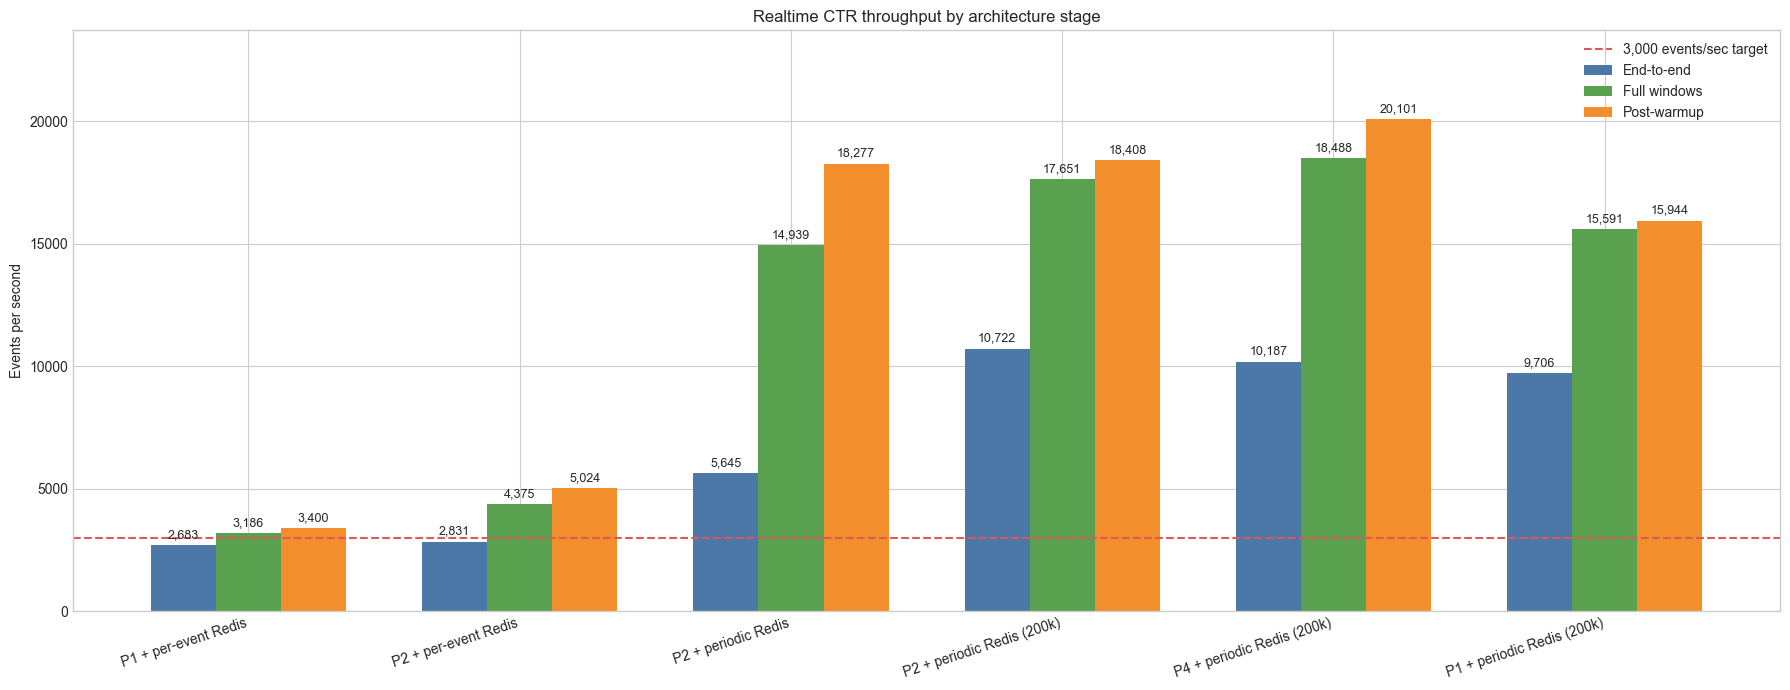

In [5]:
labels = summary["short_label"].tolist()
x = np.arange(len(labels))
width = 0.24
fig, ax = plt.subplots(figsize=(18, 7))
series = [
    ("End-to-end", "end_to_end_eps", "#4C78A8"),
    ("Full windows", "full_window_eps", "#59A14F"),
    ("Post-warmup", "post_warmup_eps", "#F28E2B"),
]
for index, (name, column, color) in enumerate(series):
    bars = ax.bar(x + (index - 1) * width, summary[column], width, label=name, color=color)
    ax.bar_label(bars, labels=[f"{value:,.0f}" for value in summary[column]], padding=3, fontsize=9)
ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1.5, label="3,000 events/sec target")
ax.set_ylabel("Events per second")
ax.set_title("Realtime CTR throughput by architecture stage")
ax.set_xticks(x, labels, rotation=18, ha="right")
ax.legend()
ax.set_ylim(0, summary[["end_to_end_eps", "full_window_eps", "post_warmup_eps"]].to_numpy().max() * 1.18)
plt.tight_layout()
plt.show()

In [6]:
baseline = summary.iloc[0]
speedups = summary[["short_label", "end_to_end_eps", "full_window_eps", "post_warmup_eps"]].copy()
for column in ("end_to_end_eps", "full_window_eps", "post_warmup_eps"):
    speedups[f"{column}_speedup"] = speedups[column] / baseline[column]
speedups[["short_label", "end_to_end_eps_speedup", "full_window_eps_speedup", "post_warmup_eps_speedup"]].style.format({
    "end_to_end_eps_speedup": "{:.2f}x",
    "full_window_eps_speedup": "{:.2f}x",
    "post_warmup_eps_speedup": "{:.2f}x",
})

,short_label,end_to_end_eps_speedup,full_window_eps_speedup,post_warmup_eps_speedup
stage,,,,
1. Initial baseline,P1 + per-event Redis,1.00x,1.00x,1.00x
2. Parallelism improvement,P2 + per-event Redis,1.06x,1.37x,1.48x
3. Periodic Redis flushing,P2 + periodic Redis,2.10x,4.69x,5.38x
4. Sustained-load validation,P2 + periodic Redis (200k),4.00x,5.54x,5.41x
5. Parallelism 4,P4 + periodic Redis (200k),3.80x,5.80x,5.91x
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),3.62x,4.89x,4.69x


## Sustained-load validation

The fourth run uses the same parallelism and Redis strategy as stage 3. Its larger backlog is a measurement-quality change, not another architecture change. It provides more full processing windows and reduces the influence of startup and trailing partial-window costs.

In [7]:
optimized_short = summary.iloc[2]
sustained = summary.iloc[3]
sustained_records = records_by_stage[sustained.name]
sustained_final = sustained_records.groupby("subtask_index", as_index=False).tail(1)
subtask_shares = sustained_final.set_index("subtask_index")["processed_events"] / sustained["processed_events"]

comparison_columns = [
    "short_label", "processed_events", "full_window_records", "elapsed_seconds",
    "end_to_end_eps", "full_window_eps", "post_warmup_eps",
    "redis_flushes", "updates_per_redis_write", "redis_write_reduction_pct",
]
display(summary.iloc[[2, 3]][comparison_columns].style.format({
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

display(Markdown(f"""
### Sustained-run reading

- The workload increased from **{int(optimized_short['processed_events']):,}** to **{int(sustained['processed_events']):,} events**, and the number of comparable full windows increased from **{int(optimized_short['full_window_records'])}** to **{int(sustained['full_window_records'])}**.
- Full-window throughput measured **{sustained['full_window_eps']:,.0f} events/sec**; post-warmup throughput measured **{sustained['post_warmup_eps']:,.0f} events/sec**. The post-warmup result changed by only **{100 * (sustained['post_warmup_eps'] / optimized_short['post_warmup_eps'] - 1):+.2f}%**, confirming stable steady-state capacity.
- End-to-end processor throughput rose from **{optimized_short['end_to_end_eps']:,.0f}** to **{sustained['end_to_end_eps']:,.0f} events/sec** because fixed startup and trailing-window costs are amortized over a longer backlog.
- Redis emitted **{int(sustained['redis_flushes']):,} writes** for **{int(sustained['processed_events']):,} valid updates**: **{sustained['updates_per_redis_write']:.1f} updates/write** and **{sustained['redis_write_reduction_pct']:.2f}%** fewer writes than per-event persistence.
- The two Flink subtasks processed **{subtask_shares.iloc[0]:.1%}** and **{subtask_shares.iloc[1]:.1%}** of events. This is reasonably balanced, though Kafka key/partition distribution still leaves some skew.
- The sustained run exceeds the 3,000 events/sec target by **{sustained['end_to_end_eps'] / 3_000:.2f}x** end to end and **{sustained['full_window_eps'] / 3_000:.2f}x** during full windows.
"""))

,short_label,processed_events,full_window_records,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
stage,,,,,,,,,,
3. Periodic Redis flushing,P2 + periodic Redis,"50,997",9,9.03,"5,645","14,939","18,277",414,123.2x,99.19%
4. Sustained-load validation,P2 + periodic Redis (200k),"204,126",40,19.04,"10,722","17,651","18,408","1,515",134.7x,99.26%



### Sustained-run reading

- The workload increased from **50,997** to **204,126 events**, and the number of comparable full windows increased from **9** to **40**.
- Full-window throughput measured **17,651 events/sec**; post-warmup throughput measured **18,408 events/sec**. The post-warmup result changed by only **+0.72%**, confirming stable steady-state capacity.
- End-to-end processor throughput rose from **5,645** to **10,722 events/sec** because fixed startup and trailing-window costs are amortized over a longer backlog.
- Redis emitted **1,515 writes** for **204,126 valid updates**: **134.7 updates/write** and **99.26%** fewer writes than per-event persistence.
- The two Flink subtasks processed **46.9%** and **53.1%** of events. This is reasonably balanced, though Kafka key/partition distribution still leaves some skew.
- The sustained run exceeds the 3,000 events/sec target by **3.57x** end to end and **5.88x** during full windows.


## Redis impact without parallelism

Stages 1 and 6 both use parallelism 1. Their main architecture difference is per-event Redis persistence versus periodic coalesced persistence. The backlog sizes differ (about 51k versus 204k events), so this is not a perfectly controlled A/B test; full-window and post-warmup rates are the fairest available comparison.

In [8]:
p1_per_event = summary.iloc[0]
p1_periodic = summary.iloc[5]
p1_comparison = summary.iloc[[0, 5]][[
    "short_label", "processed_events", "full_window_records", "end_to_end_eps",
    "full_window_eps", "post_warmup_eps", "redis_flushes",
    "updates_per_redis_write", "redis_write_reduction_pct",
]]
display(p1_comparison.style.format({
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

display(Markdown(f"""
### P1 Redis reading

- Full-window throughput increased from **{p1_per_event['full_window_eps']:,.0f}** to **{p1_periodic['full_window_eps']:,.0f} events/sec** (**{p1_periodic['full_window_eps'] / p1_per_event['full_window_eps']:.2f}x**).
- Post-warmup throughput increased from **{p1_per_event['post_warmup_eps']:,.0f}** to **{p1_periodic['post_warmup_eps']:,.0f} events/sec** (**{p1_periodic['post_warmup_eps'] / p1_per_event['post_warmup_eps']:.2f}x**).
- End-to-end processor throughput improved **{p1_periodic['end_to_end_eps'] / p1_per_event['end_to_end_eps']:.2f}x**, although part of this ratio comes from amortizing fixed costs over the larger backlog.
- The optimized P1 run replaced **{int(p1_periodic['processed_events']):,} potential per-event writes** with **{int(p1_periodic['redis_flushes']):,} Redis writes**, eliminating **{p1_periodic['redis_write_reduction_pct']:.2f}%** of writes.

The magnitude and the active-window comparison both support the same conclusion: Redis I/O in the per-event hot path was the primary P1 bottleneck. A same-size P1 per-event run would be required for a perfectly controlled numerical attribution.
"""))

,short_label,processed_events,full_window_records,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
stage,,,,,,,,,
1. Initial baseline,P1 + per-event Redis,"50,997",10,"2,683","3,186","3,400","50,997",1.0x,0.00%
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),"204,126",40,"9,706","15,591","15,944","1,640",124.5x,99.20%



### P1 Redis reading

- Full-window throughput increased from **3,186** to **15,591 events/sec** (**4.89x**).
- Post-warmup throughput increased from **3,400** to **15,944 events/sec** (**4.69x**).
- End-to-end processor throughput improved **3.62x**, although part of this ratio comes from amortizing fixed costs over the larger backlog.
- The optimized P1 run replaced **204,126 potential per-event writes** with **1,640 Redis writes**, eliminating **99.20%** of writes.

The magnitude and the active-window comparison both support the same conclusion: Redis I/O in the per-event hot path was the primary P1 bottleneck. A same-size P1 per-event run would be required for a perfectly controlled numerical attribution.


## Parallelism scaling on 200k events

Stages 4, 5, and 6 use the same deterministic 200,000-impression workload and the same periodic Redis strategy. This is the controlled comparison for parallelism 1, 2, and 4.

In [9]:
parallel_scaling = summary.iloc[[5, 3, 4]][[
    "short_label", "parallelism", "processed_events", "elapsed_seconds",
    "end_to_end_eps", "full_window_eps", "post_warmup_eps",
    "redis_flushes", "updates_per_redis_write",
]].sort_values("parallelism")
p1_200k = parallel_scaling.iloc[0]
p2_200k = parallel_scaling.iloc[1]
p4_200k = parallel_scaling.iloc[2]
parallel_scaling["full_window_speedup"] = parallel_scaling["full_window_eps"] / p1_200k["full_window_eps"]
parallel_scaling["post_warmup_speedup"] = parallel_scaling["post_warmup_eps"] / p1_200k["post_warmup_eps"]
parallel_scaling["full_window_efficiency_pct"] = 100 * parallel_scaling["full_window_speedup"] / parallel_scaling["parallelism"]
display(parallel_scaling.style.format({
    "processed_events": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "full_window_speedup": "{:.2f}x",
    "post_warmup_speedup": "{:.2f}x",
    "full_window_efficiency_pct": "{:.1f}%",
}))

p4_records = records_by_stage[summary.index[4]]
p4_final = p4_records.groupby("subtask_index", as_index=False).tail(1).sort_values("subtask_index")
p4_shares = p4_final["processed_events"] / p4_200k["processed_events"]
display(Markdown(f"""
### Scaling reading

- P1 to P2 improves full-window throughput by **{100 * (p2_200k['full_window_eps'] / p1_200k['full_window_eps'] - 1):.2f}%**, post-warmup throughput by **{100 * (p2_200k['post_warmup_eps'] / p1_200k['post_warmup_eps'] - 1):.2f}%**, and end-to-end throughput by **{100 * (p2_200k['end_to_end_eps'] / p1_200k['end_to_end_eps'] - 1):.2f}%**.
- P2 to P4 adds only **{100 * (p4_200k['full_window_eps'] / p2_200k['full_window_eps'] - 1):.2f}%** full-window and **{100 * (p4_200k['post_warmup_eps'] / p2_200k['post_warmup_eps'] - 1):.2f}%** post-warmup throughput; end-to-end throughput changes by **{100 * (p4_200k['end_to_end_eps'] / p2_200k['end_to_end_eps'] - 1):+.2f}%**.
- P4 reaches the highest active rate at **{p4_200k['full_window_eps']:,.0f} events/sec**, but P2 has the best end-to-end rate at **{p2_200k['end_to_end_eps']:,.0f} events/sec**.
- Relative to ideal linear scaling from P1, full-window efficiency is **{parallel_scaling.iloc[1]['full_window_efficiency_pct']:.1f}%** at P2 and **{parallel_scaling.iloc[2]['full_window_efficiency_pct']:.1f}%** at P4.
- P4 subtask shares range from **{p4_shares.min():.1%}** to **{p4_shares.max():.1%}**. The modest key/partition skew does not explain the full scaling gap by itself.

On this local machine, P2 is the practical throughput sweet spot: P4 consumes twice the processing lanes for a small active-window gain and no end-to-end gain. The measurements indicate local resource contention, coordination/serialization overhead, or shared external I/O limits, but this experiment does not isolate which one dominates. Repeat each setting several times before treating the small P2/P4 difference as statistically stable.
"""))

,short_label,parallelism,processed_events,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,full_window_speedup,post_warmup_speedup,full_window_efficiency_pct
stage,,,,,,,,,,,,
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),1,"204,126",21.03,"9,706","15,591","15,944","1,640",124.5x,1.00x,1.00x,100.0%
4. Sustained-load validation,P2 + periodic Redis (200k),2,"204,126",19.04,"10,722","17,651","18,408","1,515",134.7x,1.13x,1.15x,56.6%
5. Parallelism 4,P4 + periodic Redis (200k),4,"204,126",20.04,"10,187","18,488","20,101","1,279",159.6x,1.19x,1.26x,29.6%



### Scaling reading

- P1 to P2 improves full-window throughput by **13.21%**, post-warmup throughput by **15.45%**, and end-to-end throughput by **10.47%**.
- P2 to P4 adds only **4.75%** full-window and **9.20%** post-warmup throughput; end-to-end throughput changes by **-4.99%**.
- P4 reaches the highest active rate at **18,488 events/sec**, but P2 has the best end-to-end rate at **10,722 events/sec**.
- Relative to ideal linear scaling from P1, full-window efficiency is **56.6%** at P2 and **29.6%** at P4.
- P4 subtask shares range from **23.2%** to **26.7%**. The modest key/partition skew does not explain the full scaling gap by itself.

On this local machine, P2 is the practical throughput sweet spot: P4 consumes twice the processing lanes for a small active-window gain and no end-to-end gain. The measurements indicate local resource contention, coordination/serialization overhead, or shared external I/O limits, but this experiment does not isolate which one dominates. Repeat each setting several times before treating the small P2/P4 difference as statistically stable.


## Processing windows

These timelines reveal startup cost, steady-state behavior, subtask balance, and trailing partial windows. Partial windows are shown with an `x` marker and should not be used as sustained-capacity measurements.

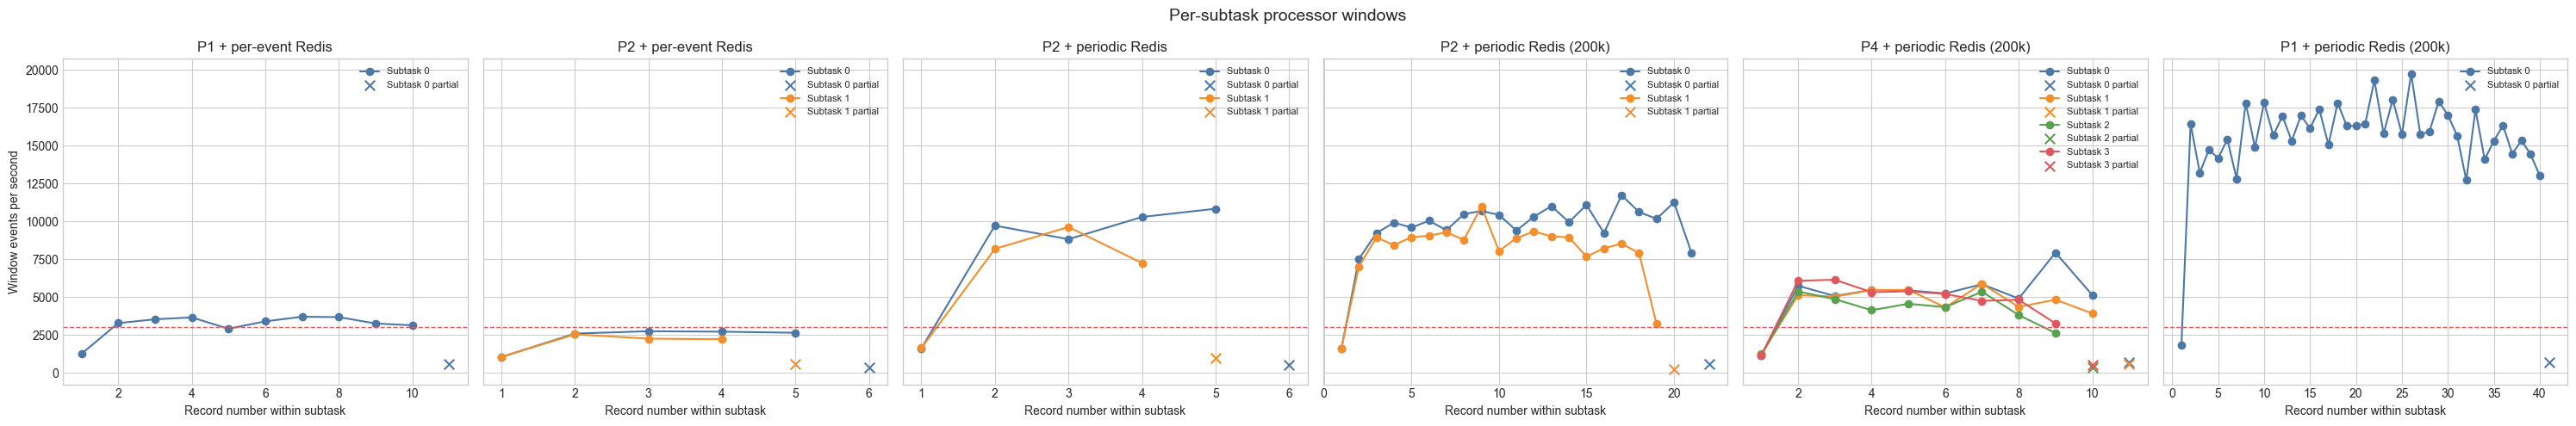

In [10]:
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(30, 5), sharey=True)
colors = ["#4C78A8", "#F28E2B", "#59A14F", "#E15759"]
for ax, experiment in zip(axes, EXPERIMENTS, strict=True):
    records = records_by_stage[experiment["stage"]]
    for color, (subtask_index, subtask) in zip(colors, records.groupby("subtask_index"), strict=False):
        max_window = subtask["window_events"].max()
        full = subtask["window_events"] == max_window
        ax.plot(subtask.loc[full, "record_index"], subtask.loc[full, "window_events_per_second"], marker="o", color=color, label=f"Subtask {subtask_index}")
        ax.scatter(subtask.loc[~full, "record_index"], subtask.loc[~full, "window_events_per_second"], marker="x", s=70, color=color, label=f"Subtask {subtask_index} partial")
    ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1)
    ax.set_title(experiment["short_label"])
    ax.set_xlabel("Record number within subtask")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Window events per second")
fig.suptitle("Per-subtask processor windows", fontsize=14)
plt.tight_layout()
plt.show()

## Redis write efficiency

Historical per-event runs did not emit flush counters. Their Redis flush count is reconstructed as one write per valid event, matching the implementation used at that time. The periodic-flush run uses recorded counters.

,short_label,valid_events,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,flush_metrics_source
stage,,,,,,,,
1. Initial baseline,P1 + per-event Redis,"50,997","50,997","50,997",0,1.0x,0.00%,Derived from historical per-event behavior
2. Parallelism improvement,P2 + per-event Redis,"50,997","50,997","50,997",0,1.0x,0.00%,Derived from historical per-event behavior
3. Periodic Redis flushing,P2 + periodic Redis,"50,997",414,"50,997","50,583",123.2x,99.19%,Recorded
4. Sustained-load validation,P2 + periodic Redis (200k),"204,126","1,515","204,126","202,611",134.7x,99.26%,Recorded
5. Parallelism 4,P4 + periodic Redis (200k),"204,126","1,279","204,126","202,847",159.6x,99.37%,Recorded
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),"204,126","1,640","204,126","202,486",124.5x,99.20%,Recorded


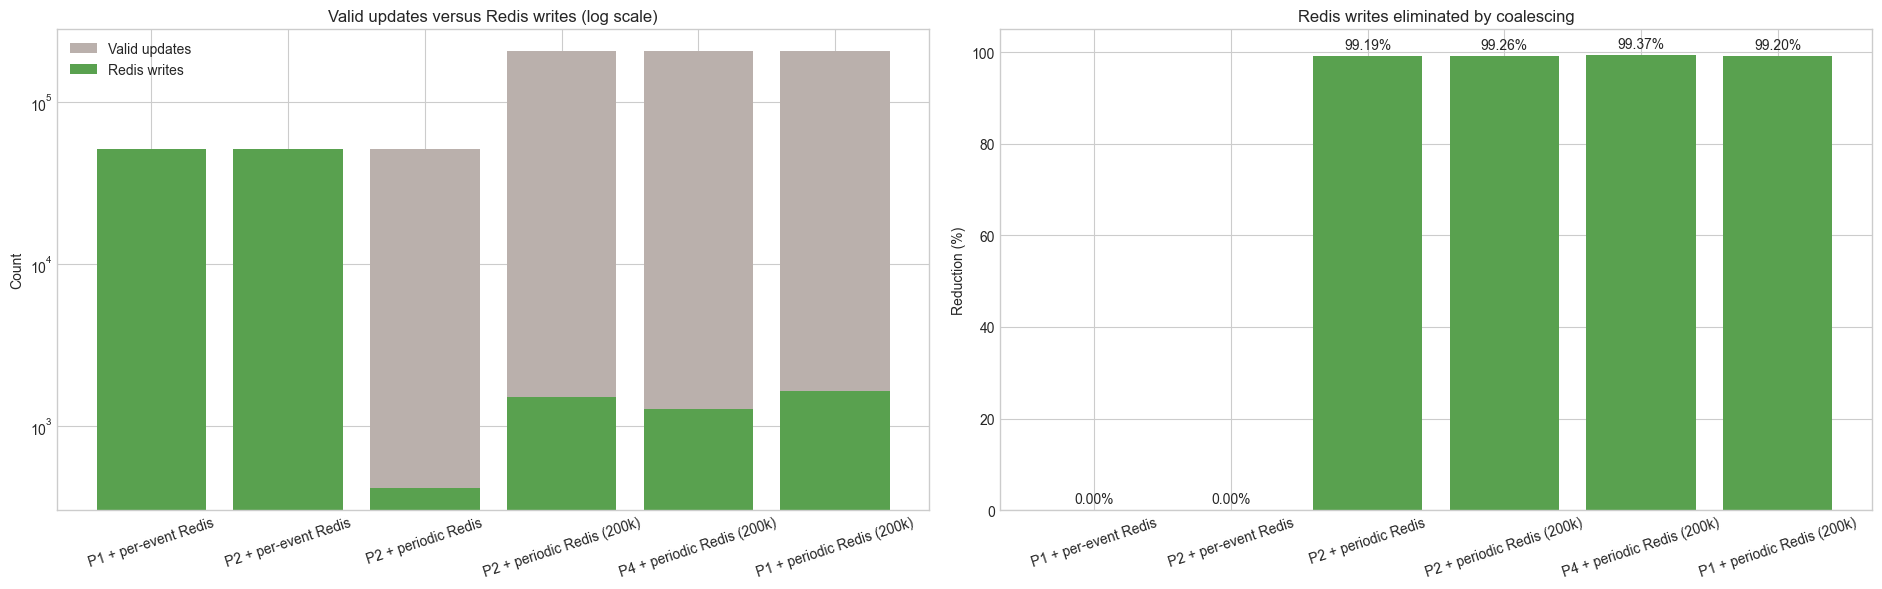

In [11]:
redis_table = summary[[
    "short_label",
    "valid_events",
    "redis_flushes",
    "redis_updates_flushed",
    "redis_updates_coalesced",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
    "flush_metrics_source",
]].copy()
display(redis_table.style.format({
    "valid_events": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
    "redis_updates_coalesced": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
axes[0].bar(labels, summary["valid_events"], color="#BAB0AC", label="Valid updates")
axes[0].bar(labels, summary["redis_flushes"], color="#59A14F", label="Redis writes")
axes[0].set_yscale("log")
axes[0].set_title("Valid updates versus Redis writes (log scale)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend()
reduction_colors = ["#59A14F" if "periodic" in label.lower() else "#BAB0AC" for label in labels]
reduction_bars = axes[1].bar(labels, summary["redis_write_reduction_pct"], color=reduction_colors)
axes[1].bar_label(reduction_bars, labels=[f"{value:.2f}%" for value in summary["redis_write_reduction_pct"]], padding=3)
axes[1].set_ylim(0, 105)
axes[1].set_title("Redis writes eliminated by coalescing")
axes[1].set_ylabel("Reduction (%)")
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

## Correctness and completeness

Performance gains are acceptable only when Kafka production, Flink processing, and Redis deltas reconcile.

In [12]:
correctness = summary[[
    "short_label",
    "produced_events",
    "processed_events",
    "dead_letters",
    "redis_impression_delta",
    "redis_click_delta",
    "redis_updates_flushed",
    "gates_passed",
]].copy()
correctness["all_events_processed"] = correctness["produced_events"] == correctness["processed_events"]
correctness["all_updates_flushed"] = correctness["processed_events"] == correctness["redis_updates_flushed"]
correctness["status"] = np.where(
    correctness[["all_events_processed", "all_updates_flushed", "gates_passed"]].all(axis=1) & (correctness["dead_letters"] == 0),
    "PASS",
    "CHECK",
)
correctness.style.format({
    "produced_events": "{:,.0f}",
    "processed_events": "{:,.0f}",
    "redis_impression_delta": "{:,.0f}",
    "redis_click_delta": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
})

,short_label,produced_events,processed_events,dead_letters,redis_impression_delta,redis_click_delta,redis_updates_flushed,gates_passed,all_events_processed,all_updates_flushed,status
stage,,,,,,,,,,,
1. Initial baseline,P1 + per-event Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS
2. Parallelism improvement,P2 + per-event Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS
3. Periodic Redis flushing,P2 + periodic Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS
4. Sustained-load validation,P2 + periodic Redis (200k),"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
5. Parallelism 4,P4 + periodic Redis (200k),"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
6. Parallelism 1 with periodic Redis,P1 + periodic Redis (200k),"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS


## Subtask distribution

Balanced final counts show whether Kafka partitions and `key_by` distribute the workload across available Flink subtasks.

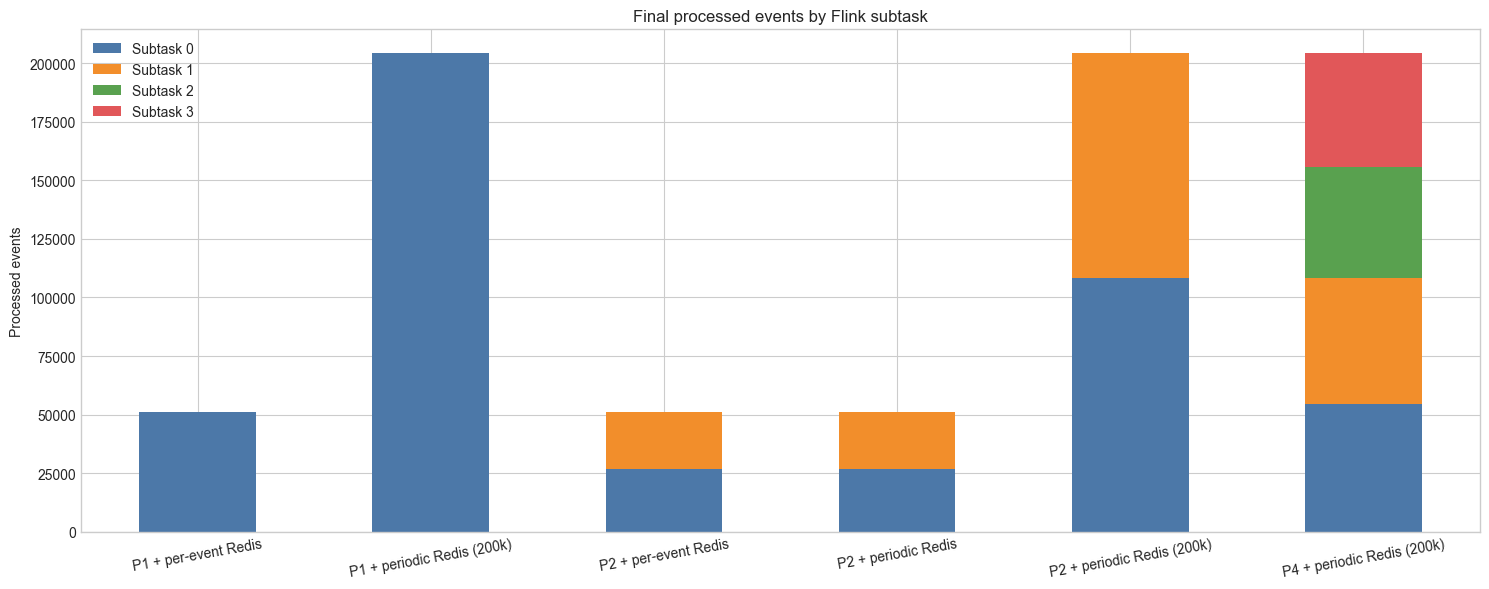

In [13]:
distribution_rows = []
for experiment in EXPERIMENTS:
    records = records_by_stage[experiment["stage"]]
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    for _, record in final_records.iterrows():
        distribution_rows.append({
            "short_label": experiment["short_label"],
            "subtask": f"Subtask {int(record['subtask_index'])}",
            "processed_events": int(record["processed_events"]),
        })
distribution = pd.DataFrame(distribution_rows).pivot(index="short_label", columns="subtask", values="processed_events").fillna(0)
ax = distribution.plot(kind="bar", stacked=True, figsize=(15, 6), color=["#4C78A8", "#F28E2B", "#59A14F", "#E15759"])
ax.set_title("Final processed events by Flink subtask")
ax.set_xlabel("")
ax.set_ylabel("Processed events")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="")
plt.tight_layout()
plt.show()

## Data-driven conclusions

In [14]:
initial = summary.iloc[0]
parallel = summary.iloc[1]
redis_optimized = summary.iloc[2]
sustained = summary.iloc[3]
parallelism_four = summary.iloc[4]
parallelism_one_optimized = summary.iloc[5]
display(Markdown(
    f"""
### What changed

- Increasing parallelism from 1 to 2 raised full-window throughput from **{initial['full_window_eps']:,.0f}** to **{parallel['full_window_eps']:,.0f} events/sec** (**{parallel['full_window_eps'] / initial['full_window_eps']:.2f}x**).
- Periodic Redis flushing then raised it to **{redis_optimized['full_window_eps']:,.0f} events/sec** (**{redis_optimized['full_window_eps'] / parallel['full_window_eps']:.2f}x** over parallelism alone).
- In the same-sized 50k experiments, the optimized architecture is **{redis_optimized['full_window_eps'] / initial['full_window_eps']:.2f}x** faster than the initial active-window baseline.
- Redis writes fell from approximately **{int(parallel['redis_flushes']):,}** to **{int(redis_optimized['redis_flushes']):,}**, a **{redis_optimized['redis_write_reduction_pct']:.2f}%** reduction while all **{int(redis_optimized['processed_events']):,}** events remained accounted for.
- The 200k sustained run then measured **{sustained['full_window_eps']:,.0f} full-window events/sec** across **{int(sustained['full_window_records'])} full windows**, while its post-warmup rate was within **{abs(100 * (sustained['post_warmup_eps'] / redis_optimized['post_warmup_eps'] - 1)):.2f}%** of the shorter optimized run.
- The sustained run accounted for all **{int(sustained['processed_events']):,} events**, averaged **{sustained['updates_per_redis_write']:.1f} bucket updates per Redis write**, and eliminated **{sustained['redis_write_reduction_pct']:.2f}%** of per-event writes.
- At P1, moving Redis writes out of the hot path raised full-window throughput from **{initial['full_window_eps']:,.0f}** to **{parallelism_one_optimized['full_window_eps']:,.0f} events/sec** (**{parallelism_one_optimized['full_window_eps'] / initial['full_window_eps']:.2f}x**), with the caveat that the optimized run used the larger backlog.
- On the controlled 200k workload, P1, P2, and P4 measured **{parallelism_one_optimized['full_window_eps']:,.0f}**, **{sustained['full_window_eps']:,.0f}**, and **{parallelism_four['full_window_eps']:,.0f} full-window events/sec**. P4 improved active throughput only modestly and did not beat P2 end to end.

### Interpretation

Parallelism improved capacity, but synchronous per-event Redis writes were the dominant bottleneck. Keeping exact state in Flink and flushing only the latest dirty bucket snapshot removed that bottleneck without losing events or Redis totals. After that optimization, additional local parallelism has sharply diminishing returns: P2 is currently the best end-to-end setting, while P4 provides only the highest active-window rate.
"""
))


### What changed

- Increasing parallelism from 1 to 2 raised full-window throughput from **3,186** to **4,375 events/sec** (**1.37x**).
- Periodic Redis flushing then raised it to **14,939 events/sec** (**3.41x** over parallelism alone).
- In the same-sized 50k experiments, the optimized architecture is **4.69x** faster than the initial active-window baseline.
- Redis writes fell from approximately **50,997** to **414**, a **99.19%** reduction while all **50,997** events remained accounted for.
- The 200k sustained run then measured **17,651 full-window events/sec** across **40 full windows**, while its post-warmup rate was within **0.72%** of the shorter optimized run.
- The sustained run accounted for all **204,126 events**, averaged **134.7 bucket updates per Redis write**, and eliminated **99.26%** of per-event writes.
- At P1, moving Redis writes out of the hot path raised full-window throughput from **3,186** to **15,591 events/sec** (**4.89x**), with the caveat that the optimized run used the larger backlog.
- On the controlled 200k workload, P1, P2, and P4 measured **15,591**, **17,651**, and **18,488 full-window events/sec**. P4 improved active throughput only modestly and did not beat P2 end to end.

### Interpretation

Parallelism improved capacity, but synchronous per-event Redis writes were the dominant bottleneck. Keeping exact state in Flink and flushing only the latest dirty bucket snapshot removed that bottleneck without losing events or Redis totals. After that optimization, additional local parallelism has sharply diminishing returns: P2 is currently the best end-to-end setting, while P4 provides only the highest active-window rate.


## Extending the history

For each new controlled experiment, add one entry to `EXPERIMENTS` with its artifact path, configured parallelism, and Redis strategy. Keep workload size, random seed, topics, and machine environment unchanged when comparing one optimization.

The 200,000-impression workload is now the scalability reference. Keep the random seed, Kafka partitions, Redis flush settings, and machine environment fixed. Run each P1/P2/P4 setting at least three times and compare medians and variability before making the final scaling claim.